<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%203/03_returns_and_discount.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Returns and Discount Factor
**Week 3 | RL Fundamentals**

The **return** G_t is the cumulative reward from time t onwards:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

The discount factor γ ∈ [0,1) controls how much the agent cares about future rewards.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Computing Returns

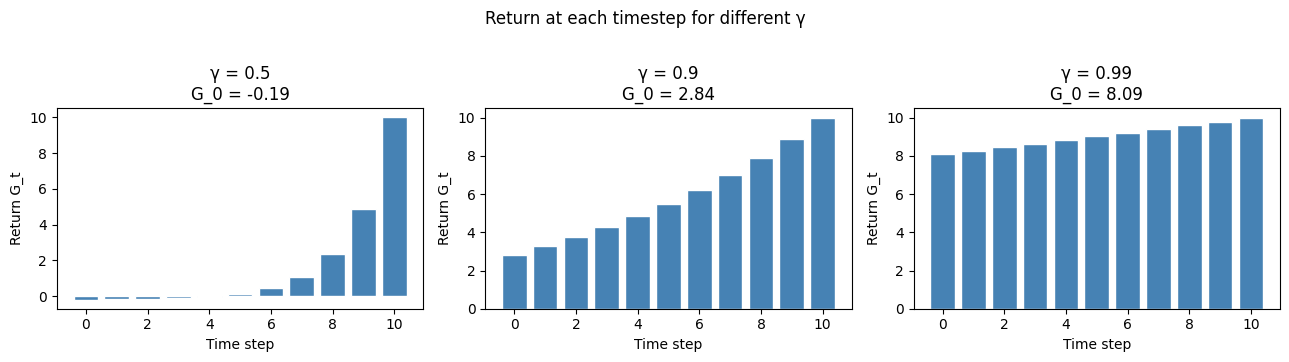

In [2]:
def compute_returns(rewards, gamma):
    """Compute discounted returns for a list of rewards (backwards pass)."""
    G = np.zeros(len(rewards))
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        G[t] = running
    return G

# Example trajectory: -0.1 per step, +10 at end
rewards = [-0.1] * 10 + [10.0]
t = np.arange(len(rewards))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, gamma in zip(axes, [0.5, 0.9, 0.99]):
    G = compute_returns(rewards, gamma)
    ax.bar(t, G, color='steelblue', edgecolor='white')
    ax.set_title(f'γ = {gamma}\nG_0 = {G[0]:.2f}')
    ax.set_xlabel('Time step'); ax.set_ylabel('Return G_t')
plt.suptitle('Return at each timestep for different γ', y=1.02)
plt.tight_layout(); plt.show()

## 2. Effect of γ on Discount Weights

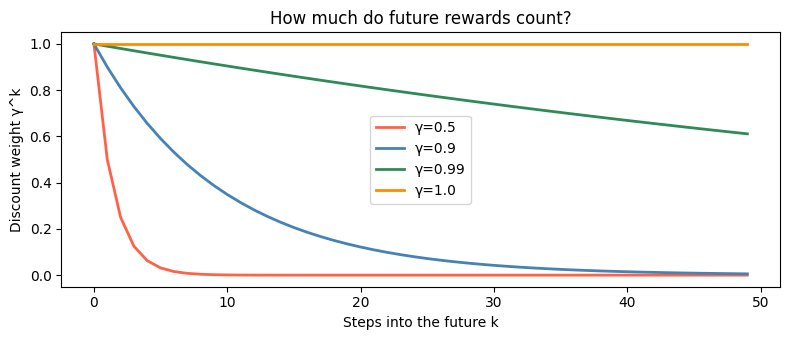


A reward 20 steps away is worth:
  γ=0.5: 0.0000 of its face value
  γ=0.9: 0.1216 of its face value
  γ=0.99: 0.8179 of its face value
  γ=1.0: 1.0000 of its face value


In [3]:
steps = np.arange(0, 50)
fig, ax = plt.subplots(figsize=(8, 3.5))
for gamma, color in [(0.5,'tomato'),(0.9,'steelblue'),(0.99,'seagreen'),(1.0,'darkorange')]:
    weights = gamma ** steps
    ax.plot(steps, weights, label=f'γ={gamma}', linewidth=2, color=color)
ax.set_xlabel('Steps into the future k')
ax.set_ylabel('Discount weight γ^k')
ax.set_title('How much do future rewards count?')
ax.legend(); plt.tight_layout(); plt.show()
print("\nA reward 20 steps away is worth:")
for g in [0.5, 0.9, 0.99, 1.0]:
    print(f"  γ={g}: {g**20:.4f} of its face value")

## 3. Episodic vs Continuing Tasks

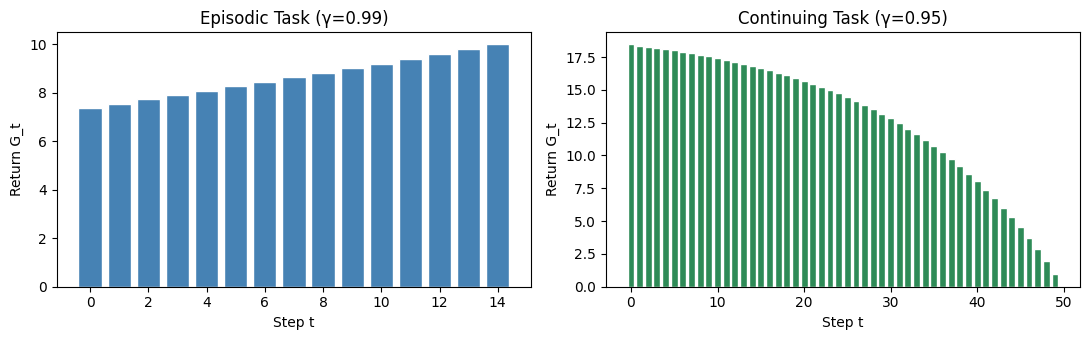

Continuing task: geometric series limit = R/(1-γ) = 20.0
Empirical G_0 = 18.46


In [4]:
# Episodic: trajectory has a natural end (e.g. reaching the goal)
def episodic_returns(n_steps=15, goal_reward=10.0, step_cost=-0.1, gamma=0.99):
    rewards = [step_cost] * (n_steps-1) + [goal_reward]
    return compute_returns(rewards, gamma)

# Continuing: no terminal state; must use discounting to keep G finite
def continuing_returns(n_steps=50, reward_per_step=1.0, gamma=0.95):
    rewards = [reward_per_step] * n_steps
    return compute_returns(rewards, gamma)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
g_ep = episodic_returns()
axes[0].bar(range(len(g_ep)), g_ep, color='steelblue', edgecolor='white')
axes[0].set_title('Episodic Task (γ=0.99)')
axes[0].set_xlabel('Step t'); axes[0].set_ylabel('Return G_t')

g_cont = continuing_returns()
axes[1].bar(range(len(g_cont)), g_cont, color='seagreen', edgecolor='white')
axes[1].set_title('Continuing Task (γ=0.95)')
axes[1].set_xlabel('Step t'); axes[1].set_ylabel('Return G_t')
plt.tight_layout(); plt.show()

print(f"Continuing task: geometric series limit = R/(1-γ) = {1.0/(1-0.95):.1f}")
print(f"Empirical G_0 = {g_cont[0]:.2f}")

## 4. The Bellman Equation for Returns
G_t = R_{t+1} + γ * G_{t+1}  — the key recursive structure used by all RL algorithms.

In [5]:
rewards = np.random.randn(20)  # random rewards
gamma   = 0.9
G = compute_returns(rewards, gamma)

# Verify Bellman equation: G[t] == rewards[t+1] + gamma * G[t+1]
for t in range(len(G)-1):
    lhs = G[t]
    rhs = rewards[t] + gamma * G[t+1]
    assert np.isclose(lhs, rhs), f"Mismatch at t={t}: {lhs:.4f} vs {rhs:.4f}"
print("✅ Bellman equation verified for all timesteps")

✅ Bellman equation verified for all timesteps


## ✅ Exercises
1. Set γ=0 and γ=1 and describe what kind of agent each creates. Is γ=1 ever safe for a continuing task?
2. Compute the optimal γ for a task where rewards are [1, 1, 1, ..., 100] after 50 steps. At what γ does the far reward contribute at least 50% of G_0?
3. **Challenge**: implement `compute_returns_forward` — compute G_t without reversing the array (hint: use the geometric series formula).

### Exercise 1 & 2: Conceptual Analysis

**1. Effect of Extreme γ values:**
* `γ = 0`: The agent is completely short-sighted (myopic). It only considers the immediate reward $R_{t+1}$ and ignores all future consequences.
* `γ = 1`: The agent is perfectly far-sighted, weighing rewards 1000 steps away equally to immediate rewards.
* *Is γ=1 safe for continuing tasks?* No. If the task never ends, the sum of rewards (even small ones like +1) will diverge to infinity, making it mathematically impossible for the agent to compare which policy is actually better.

**2. Calculating threshold γ for a delayed reward:**
To make a reward of 100 at step $k=50$ contribute at least 50% to $G_0$, we need the discounted value of 100 to be $\ge 50$.
* $100 \cdot \gamma^{50} \ge 50$
* $\gamma^{50} \ge 0.5$
* $\gamma \ge (0.5)^{(1/50)}$
* $\gamma \ge 0.9862$

In [7]:
# Exercise 3: Forward-pass computation of returns (O(N^2) complexity)
def compute_returns_forward(rewards, gamma):
    N = len(rewards)
    G = np.zeros(N)

    for t in range(N):
        # Slice the remaining rewards from t to the end
        future_rewards = rewards[t:]

        # Generate the discount weights: [gamma^0, gamma^1, gamma^2, ...]
        powers = np.arange(len(future_rewards))
        discounts = gamma ** powers

        # Dot product of rewards and their corresponding discount weights
        G[t] = np.dot(future_rewards, discounts)

    return G

# Let's test it against the original backwards method to ensure accuracy
test_rewards = [1.0, 2.0, -1.0, 4.0, 10.0]
gamma_test = 0.9

g_back = compute_returns(test_rewards, gamma_test)
g_fwd = compute_returns_forward(test_rewards, gamma_test)

print("Original (Backwards):", np.round(g_back, 4))
print("Challenge (Forward): ", np.round(g_fwd, 4))
assert np.allclose(g_back, g_fwd), "Mismatch between forward and backward calculations!"
print("Success! Both methods yield identical returns.")

Original (Backwards): [11.467 11.63  10.7   13.    10.   ]
Challenge (Forward):  [11.467 11.63  10.7   13.    10.   ]
Success! Both methods yield identical returns.
